**Aims:** Extract results from the CRISPRa/i screen processing outputs and generate plots for the manuscript.

- CRISPRi-v2 screens
    - [x] PCA plot
    - [x] Scatter plot comparing scores across replicates
    - [x] UpSet plot
    - [x] Pathway enrichment plot
    - [x] Common hit spider plot
    - [x] Table S1
        - [x] Annotate `ScreenPro2` outputs for CRISPRi-v2 screens
        - [x] Run GSEA enrichment analysis of GO biological processes for rho scores of each treatment vs. DMSO
    
- CRISPRa-v2 screens
    - [x] PCA plot
    - [x] UpSet plot
    - [x] Table S2
        - [x] Annotate `ScreenPro2` outputs for CRISPRa-v2 screens
        - [x] Run GSEA enrichment analysis of GO biological processes for rho scores of each treatment vs. DMSO
<!-- - [ ] Can you do a scatter plot to replace the one in Fig S1c? -->

<!-- 

    T0: First timepoint 
    (Time Zero, after selection of cells with sgRNA library, and starting point of drug dosing)
    DMSO: DMSO treated 
    Pi: PARP inhibitor (olaparib; AZD2281)
    Ri: ATR inhibitor (AZD6738)
    Wi: WEE1 inhibitor (AZD1775)
    Mi: ATM inhibitor (AZD0156)
    Ki: DNAPK inhibitor (AZD7648)


    PiRi: PARP inhibitor + ATR inhibitor
    PiWi: PARP inhibitor + WEE1 inhibitor
    PiMi: PARP inhibitor + ATM inhibitor
    PiKi: PARP inhibitor + DNAPK inhibitor 
-->

### Setup python session

In [1]:
# !pip uninstall -y screenpro2
# !pip install git+https://github.com/ArcInstitute/screenpro2.git@dev
# # !pip install ScreenPro2

In [2]:
from glob import glob

import numpy as np
import pandas as pd 
import anndata as ad
import scanpy as sc

import screenpro as scp
import blitzgsea as blitz

import matplotlib.pyplot as plt

In [3]:
import datetime

import seaborn as sns
import upsetplot as up

import matplotlib
import matplotlib.ticker as ticker

from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import font_manager as fm
from matplotlib import rcParams, rc_context

from screenpro.plotting._utils import almost_black, dark2


matplotlib.use('cairo')

font_files = fm.findSystemFonts(fontpaths='/khayyam/abe/fonts/', fontext='ttf')

for font_file in font_files:
    fm.fontManager.addfont(font_file)


# {f.name for f in matplotlib.font_manager.fontManager.ttflist}

rcParams['font.sans-serif'] = 'Helvetica'
rcParams['font.family'] = ['Helvetica']
rcParams['figure.dpi'] = 140

rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42

In [4]:
import plotnine as p9

_ = p9.theme_set(p9.theme_matplotlib())

In [5]:
drug_names = {
    'DMSO': 'DMSO', # Vehicle
    'Pi': 'PARPi',
    'Ri': 'ATRi',
    'Wi': 'WEE1i',
    'Mi': 'ATMi',
    'Ki': 'DNAPKi',
    'PiRi': 'PARPi+ATRi',
    'PiWi': 'PARPi+WEE1i',
    'PiMi': 'PARPi+ATMi',
    'PiKi': 'PARPi+DNAPKi'
}

In [6]:
### get result tables: gene level scores with out negative controls
def getAnnotatedTables(screen, threshold):
    return dict([
        (phenotype_name, 
         screen.getPhenotypeScores(
             run_name='compare_guides',phenotype_name=phenotype_name,threshold=threshold, pvalue_col='ttest pvalue'
         )#.query('target!="negative_control"').set_index(['target','transcript'])
         )
        for phenotype_name in screen.listPhenotypeScores(run_name='compare_guides')
    ])


### get annotated result table: rho scores
def get_annotated_result_table(screen,threshold=6):
    return pd.concat(dict([
        (
            k.replace(k.split(':')[1].split('_vs_')[0], drug_names[k.split(':')[1].split('_vs_')[0]]), 
            table
        ) for k, table in getAnnotatedTables(screen, threshold=threshold).items()
        if 'rho' in k or 'gamma' in k
    ]),axis=1).dropna()

In [7]:
### pathway analysis
pager_dir = "/khayyam/abe/tools/pager/"
pager_annotation_path = '/khayyam/abe/tools/pager/annotations/human'

c5_gobp_gmt = blitz.enrichr.read_gmt(
    f'{pager_annotation_path}/msigdb_v7.4_c5.go.bp/c5.go.bp.v7.4.symbols.gmt'
)


def run_rho_gsea_directional(df,var_col,gmt,min_size=15,max_size=150):
    signature = df.query('target!="negative_control"').set_index('target')[var_col].reset_index().copy()

    result = blitz.gsea(
        signature=signature,
        library=gmt,
        min_size=min_size,
        max_size=max_size,
        verbose=True
    )
    
    return signature, result

___

### Load Data
Load Screen Processing guide level and gene level result tables.

In [8]:
crispra_v2_screen = scp.load._read_screen_pkl('../screens/A549_CRISPRa_v2_screens')
crispri_v2_screen = scp.load._read_screen_pkl('../screens/A549_CRISPRi_v2_screens')

___

In [9]:
crispra_v2_screen_result_tables = get_annotated_result_table(crispra_v2_screen)
crispri_v2_screen_result_tables = get_annotated_result_table(crispri_v2_screen)

/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


### Evaluate known DDR genes
Using previous screens using same drug treatments

In [10]:
from matplotlib_venn import venn2

ATRi_gold_standard 117 ... 89
ATMi_gold_standard 68 ... 55
WEE1i_gold_standard 110 ... 109


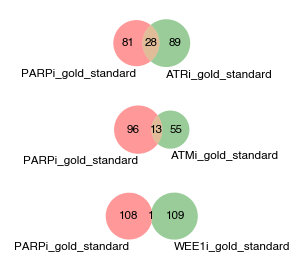

In [11]:
%matplotlib inline

# read list of genes
gold_standard_hits = {
    # Source: 
    'PARPi_gold_standard': \
        set(pd.read_csv('../gold_standard_screens/PARPi_common_hits.txt', header=None)[0].tolist()),
    'ATRi_gold_standard': \
        set(pd.read_csv('../gold_standard_screens/ATRi_common_hits.txt', header=None)[0].tolist()),
    'ATMi_gold_standard': \
        set(pd.read_csv('../gold_standard_screens/ATMi_common_hits.txt', header=None)[0].tolist()),
    'WEE1i_gold_standard': \
        set(pd.read_csv('../gold_standard_screens/WEE1i_common_hits.txt', header=None)[0].tolist()),
}

# venn2 diagram to show overlap
fig0, axes = plt.subplots(3,1, figsize=(2,2))

for i, (gs_name, gs_hits) in enumerate(gold_standard_hits.items()):
    if gs_name != 'PARPi_gold_standard':
        v = venn2(
            subsets = (
                len(gold_standard_hits['PARPi_gold_standard'] - gs_hits),
                len(gs_hits - gold_standard_hits['PARPi_gold_standard']),
                len(gold_standard_hits['PARPi_gold_standard'].intersection(gs_hits))
            ),
            set_labels = ('PARPi_gold_standard', gs_name),
            ax=axes[i-1]
        )

        for text in v.set_labels:
            text.set_fontsize(6)
        for text in v.subset_labels:
            text.set_fontsize(6)

fig0.tight_layout()

# exclude PARP genes from other gold standards
for gs_name, gs_hits in gold_standard_hits.items():
    if gs_name != 'PARPi_gold_standard':
        gold_standard_hits[gs_name] = list(set(gs_hits) - set(gold_standard_hits['PARPi_gold_standard']))
        print (gs_name, len(gs_hits), end=' ... ')
        print (len(gold_standard_hits[gs_name]))

In [12]:
gold_standard_gsea_results = {}

for drug_name in crispri_v2_screen_result_tables.columns.get_level_values(0).unique():

    if 'rho' in drug_name and '+' not in drug_name:
        
        print(drug_name)
        
        df = crispri_v2_screen_result_tables[drug_name].copy()
        # df['-log10(pvalue)'] = -np.log10(df['ttest pvalue'])
        
        sig, res = run_rho_gsea_directional(
            df,
            # var_col='-log10(pvalue)',
            var_col='score',
            gmt=gold_standard_hits
        )

        treatment = drug_name.split('_vs_')[0].replace('rho:','')

        gold_standard_gsea_results[treatment] = {
            'signature': sig,
            'result': res
        }

rho:PARPi_vs_DMSO


Enrichment : 100%|██████████| 4/4 [00:00<00:00, 287.75it/s]


rho:ATRi_vs_DMSO


Enrichment : 100%|██████████| 4/4 [00:00<00:00, 478.58it/s]


rho:ATMi_vs_DMSO


Enrichment : 100%|██████████| 4/4 [00:00<00:00, 537.25it/s]

rho:WEE1i_vs_DMSO



Enrichment : 100%|██████████| 4/4 [00:00<00:00, 957.17it/s]

rho:DNAPKi_vs_DMSO



Enrichment : 100%|██████████| 4/4 [00:00<00:00, 909.09it/s]


In [13]:
df = pd.concat(
    dict([ (k, v['result']) for k, v in gold_standard_gsea_results.items()]), 
    names=['Inhibitor','Term']).reset_index()
df['-log10(FDR)'] = -np.log10(df['fdr']).astype(int)
# df = df[~df['Inhibitor'].str.contains('\\+')]
df.sort_values('nes', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

In [15]:
df.to_excel('../tables/Table_gold_standard_gsea_results_CRISPRi_v2.xlsx', index=False)

---

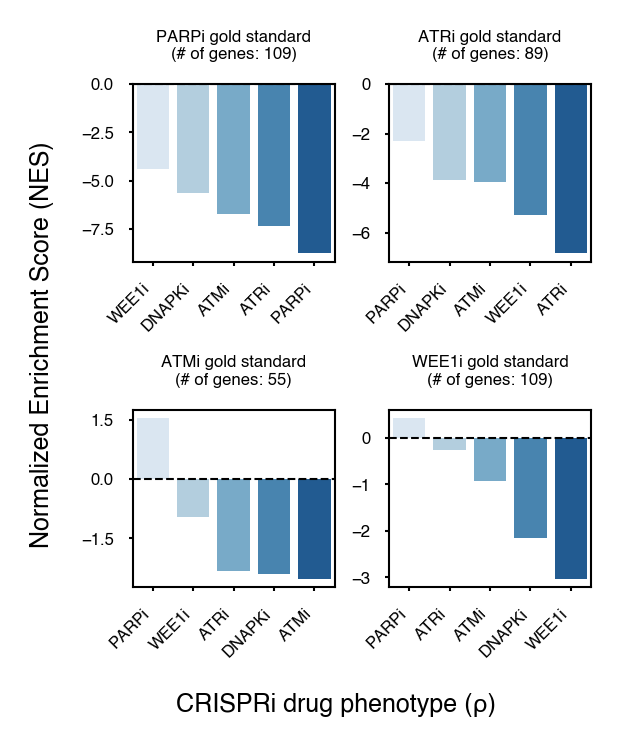

In [14]:
def plot_nes_barplot(data, term, ax, title):
    sns.barplot(
        data=data.query(f'Term=="{term}"'),
        x='Inhibitor',
        y='nes',
        palette='Blues',
        ax=ax
    )
    ax.set_title(title, fontsize=4)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.tick_params(width=.5)
    for i in ax.spines.values(): i.set_linewidth(.5)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontsize(4)
    # ticks font size
    ax.tick_params(axis='both', which='minor', labelsize=4, length=0)
    ax.tick_params(axis='both', which='major', labelsize=4, length=1)
    # set number of y ticks to 5
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    

fig1, axes = plt.subplots(2, 2, figsize=(2, 2.4), dpi=300)#, gridspec_kw={'wspace': 0.4, 'left': .2, 'top': .8, 'bottom': .3})

axes = axes.flatten()
for i, gold_std in enumerate(gold_standard_hits.keys()):
    plot_nes_barplot(df, gold_std, axes[i], title=f"{gold_std.replace('_',' ')}\n(# of genes: {len(gold_standard_hits[gold_std])})")

# set a single x / y label for all axes 
fig1.text(0.5, -0.01, 'CRISPRi drug phenotype (ρ)', ha='center', fontsize=6)
fig1.text(-0.01, 0.5, 'Normalized Enrichment Score (NES)', va='center', rotation='vertical', fontsize=6)

# rotate x labels
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

fig1.tight_layout(h_pad=0.5, w_pad=0.4)

In [15]:
# Save the plot as a PDF
with PdfPages('../plots/A549__CRISPRi_v2__gold_standard_gsea_bar_plots.pdf') as pdf:
    pdf.savefig(fig0, bbox_inches='tight')  # saves the current figure into a pdf page
    pdf.savefig(fig1, bbox_inches='tight')  # saves the current figure into a pdf page

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


### Volcano Plots

In [16]:
drug_names

{'DMSO': 'DMSO',
 'Pi': 'PARPi',
 'Ri': 'ATRi',
 'Wi': 'WEE1i',
 'Mi': 'ATMi',
 'Ki': 'DNAPKi',
 'PiRi': 'PARPi+ATRi',
 'PiWi': 'PARPi+WEE1i',
 'PiMi': 'PARPi+ATMi',
 'PiKi': 'PARPi+DNAPKi'}

In [111]:
# find overlap between hits in gold standard and screen results
overlap_results = {}

for drug in ['Pi', 'Ri', 'Wi', 'Mi']:

    treatment = drug_names[drug]
    print(f"Processing {treatment} ...")
    df = crispri_v2_screen.getPhenotypeScores(
        run_name='compare_guides',
        phenotype_name=f'rho:{drug}_vs_DMSO',
        threshold=9,
        pvalue_col='ttest pvalue'
    ).query('target!="negative_control" & label.isin(["sensitivity_hit"])').sort_values('combined_score', ascending=True)
    
    if drug == 'Pi':
        df = df.head(10)
    elif drug == 'Ri':
        df = df.head(25)
    hits = set(df['target'].tolist())
    
    ol = hits.intersection(gold_standard_hits.get(f'{treatment}_gold_standard', set()))
    
    top_hits = set(df['target'].tolist()[:5])

    overlap_results[treatment] = {
        # 'hits': hits,
        # 'gold_standard_hits': gold_standard_hits.get(f'{treatment}_gold_standard', set()),
        'sel_hits': list(set(top_hits).union(ol))
    }

    print(f'# of hits: {len(hits)}')
    print(f'# of gold standard hits: {len(gold_standard_hits.get(f"{treatment}_gold_standard", set()))}')
    print(f'# of selected hits (top 20 + overlap): {len(overlap_results[treatment]["sel_hits"])}')
    

Processing PARPi ...
# of hits: 10
# of gold standard hits: 109
# of selected hits (top 20 + overlap): 8
Processing ATRi ...
# of hits: 25
# of gold standard hits: 89
# of selected hits (top 20 + overlap): 10
Processing WEE1i ...
# of hits: 298
# of gold standard hits: 109
# of selected hits (top 20 + overlap): 9
Processing ATMi ...
# of hits: 224
# of gold standard hits: 55
# of selected hits (top 20 + overlap): 7


In [112]:
overlap_results['DNAPKi'] = {
    'sel_hits': crispri_v2_screen.getPhenotypeScores(
        run_name='compare_guides',
        phenotype_name='rho:Ki_vs_DMSO',
        threshold=6,
        pvalue_col='ttest pvalue'
    ).query('target!="negative_control" & label.isin(["sensitivity_hit"])').sort_values('combined_score', ascending=True).head(10)['target'].to_list()
}

In [113]:
def add_curve_line(ax, df, threshold, target_col='label', score_col='score', ctrl_label='negative_control', color='gray', linestyle='--', lw=0.5, **kwargs):
    # Compute pseudo standard deviation from control group
    pseudo_sd = df.loc[df[target_col] == ctrl_label, score_col].std()

    # Define curve function (no need for sign term now — we'll plot both ±)
    def draw_threshold(x):
        return threshold * pseudo_sd / np.abs(x)

    # Generate range of x values based on data
    x_vals = np.linspace(df[score_col].min(), df[score_col].max(), 500)
    x_vals = x_vals[x_vals != 0]  # avoid division by zero

    # Compute positive and negative curves
    y_pos = draw_threshold(x_vals)
    y_neg = -draw_threshold(x_vals)

    # Plot both curves
    ax.plot(x_vals, y_pos, linestyle=linestyle, color=color, label=f'+ threshold × {threshold}', lw=lw, **kwargs)
    ax.plot(x_vals, y_neg, linestyle=linestyle, color=color, label=f'- threshold × {threshold}', lw=lw, **kwargs)

    # Return ax for chaining
    return ax


In [114]:
help(crispri_v2_screen.drawVolcano)

Help on method drawVolcano in module screenpro.assays:

drawVolcano(ax, phenotype_name, threshold, dot_size=1, run_name='auto', score_col='score', pvalue_col='pvalue', xlabel='auto', ylabel='-log10(pvalue)', xlims='auto', ylims='auto', ctrl_label='negative_control', resistance_hits=None, sensitivity_hits=None, size_txt=None, t_x=0, t_y=0, **args) method of screenpro.assays.PooledScreens instance



In [115]:
# %matplotlib inline

# def draw_threshold(x):
#     return threshold * pseudo_sd * np.sign(x) / x


# volcano_plots = {}

# for ax, drug in zip(axes, dict([(k,v) for k,v in drug_names.items() if k != 'DMSO']).keys()):

#     treatment = drug_names[drug]

#     df = crispri_v2_screen.getPhenotypeScores(
#         run_name='compare_guides',
#         phenotype_name=f'rho:{drug}_vs_DMSO',
#         threshold=6,
#         pvalue_col='ttest pvalue'
#     )

#     # Convert p-values to -log10 scale
#     df['neglog10_p'] = -np.log10(df['ttest pvalue'])

#     # Optional: highlight specific subsets if available
#     sen_labels = label_sen_hits.get(drug_names[drug], [])

#     # Create plot
#     vol = (
#         p9.ggplot(df, p9.aes(x='score', y='neglog10_p', color='label'))
#         # # Add curve lines
#         # + p9.geom_line(
#         #     curve_df,
#         #     p9.aes(x='x', y='y'),
#         #     linetype='dashed',
#         #     color='black',
#         #     size=0.5
#         # )
#         + p9.geom_point(alpha=0.2, size=1)
#         # Highlight sensitizing hits
#         + p9.geom_point(
#             df.query('target in @sen_labels'),
#             p9.aes(x='score', y='neglog10_p'),
#             color='#3182bd', 
#             size=2,
#             alpha=.5
#         )
#         # Label key targets
#         + p9.geom_text(
#             df.query('target in @sen_labels'),
#             p9.aes(label='target'),
#             size=8,
#             color='black',
#             nudge_x=0.5,
#             nudge_y=0.5,
#             adjust_text = {
#             'expand_points': (4, 4),
#             'arrowprops': {
#                 'arrowstyle': '-',
#                 'color': 'black',
#                 'alpha': 0.5,
#                 }
#             }
#         )
#         + p9.scale_color_manual(values=['#bdd7e7', '#fcae91', 'lightgray', 'gray'])
#         + p9.labs(
#             x='CRISPRi drug phenotype (ρ)',
#             y=r'$-log_{10}(pvalue)$',
#             title=drug_names[drug]
#         )
#         + p9.theme_classic()
#         + p9.theme(
#             legend_position='none',
#             axis_text_x=p9.element_text(size=10, color='black'),
#             axis_text_y=p9.element_text(size=10, color='black'),
#             axis_title_x=p9.element_text(size=12),
#             axis_title_y=p9.element_text(size=12),
#             plot_title=p9.element_text(size=13, weight='bold'),
#             figure_size=(3, 5)
#         )
#     )

#     volcano_plots[treatment] = vol
    

In [116]:
hits_common_sen = [
    # 'CDK12', 
    # 'MCPH1', 
    'PRDX1', 
    'RAD9A', 
    # 'RFC5', 
    'XRCC3'
]

label_sen_hits = {
    # 'PARPi': ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
    'PARPi': list(overlap_results['PARPi']['sel_hits']) + hits_common_sen,
    # 'ATRi':  ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
    'ATRi': list(overlap_results['ATRi']['sel_hits']) + hits_common_sen,
    # 'ATMi':  ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
    'ATMi': list(overlap_results['ATMi']['sel_hits']) + hits_common_sen,
    # 'WEE1i': ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1','PKMYT1'] + hits_common_sen,
    'WEE1i': list(overlap_results['WEE1i']['sel_hits']) + hits_common_sen,
    # 'DNAPKi':['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
    'DNAPKi': list(overlap_results['DNAPKi']['sel_hits']) + hits_common_sen,
}
# drop duplicates
for k in label_sen_hits.keys():
    label_sen_hits[k] = list(set(label_sen_hits[k]))

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


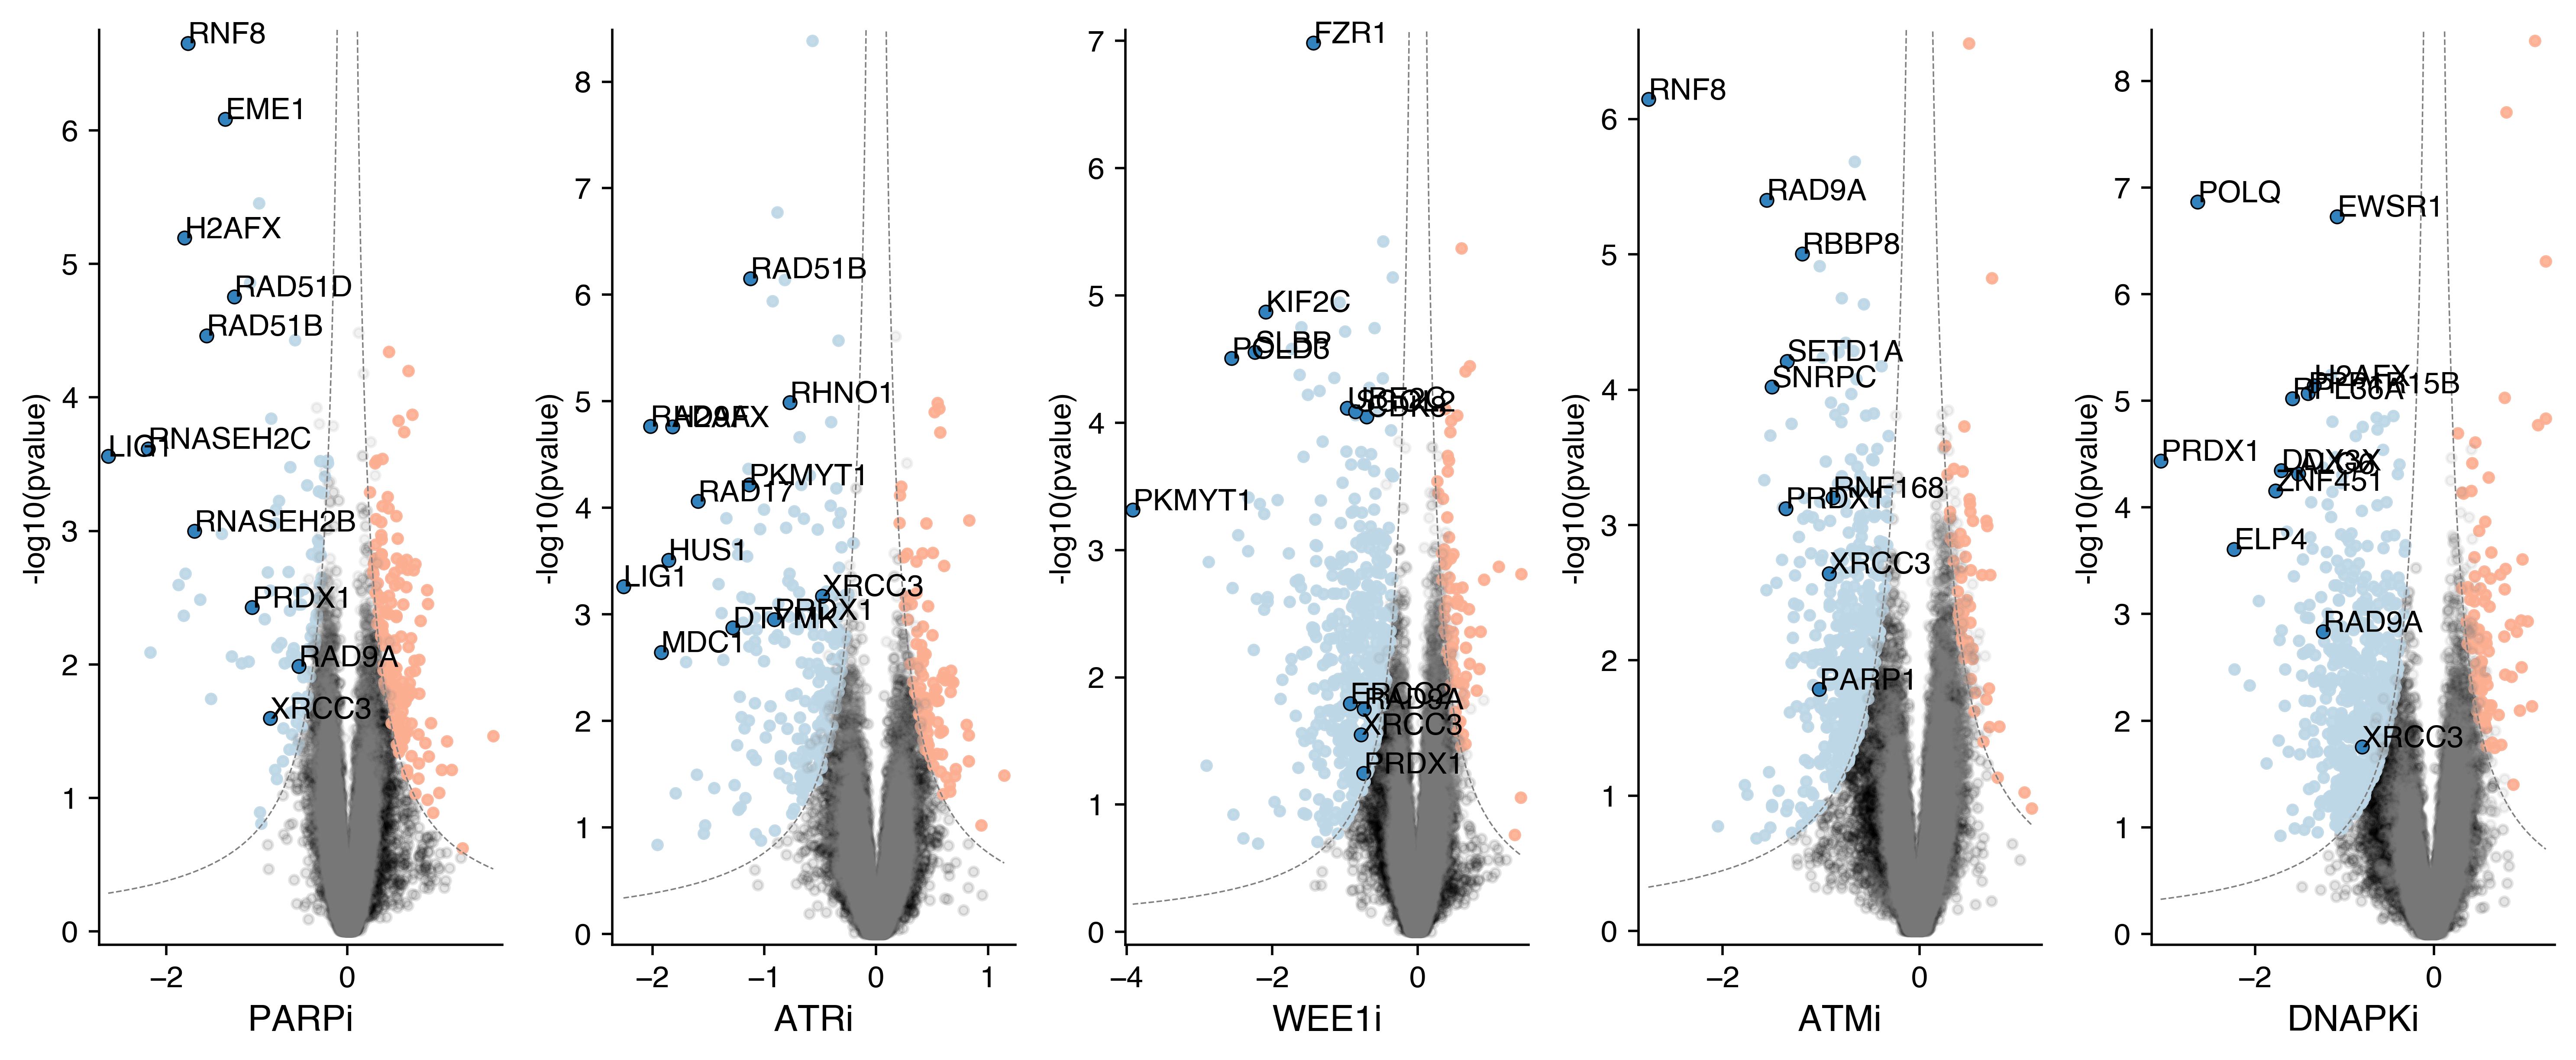

In [117]:
%matplotlib inline
fig, axes = plt.subplots(1, 5, figsize=(12, 5), dpi=500)

for ax, drug in zip(axes, dict([(k,v) for k,v in drug_names.items() if k != 'DMSO']).keys()):

    crispri_v2_screen.drawVolcano(
        ax,
        run_name='compare_guides',
        phenotype_name=f'rho:{drug}_vs_DMSO',
        dot_size=10,
        threshold=6,
        pvalue_col='ttest pvalue',
        sensitivity_hits=label_sen_hits[drug_names[drug]],
        size_txt=10
    )

    df = crispri_v2_screen.getPhenotypeScores(
        run_name='compare_guides',
        phenotype_name=f'rho:{drug}_vs_DMSO',
        threshold=6,
        pvalue_col='ttest pvalue'
    )
    
    # rasterized=True
    plt.setp(ax.collections, rasterized=True)

    # add curve line
    # add_curve_line(ax,df, threshold=1)
    # add_curve_line(ax,df, threshold=3)
    add_curve_line(ax,df, threshold=6)
    
    # set full drug name on x-axis label
    ax.set_xlabel(drug_names[drug], fontsize=12)

    # remove legend
    ax.legend_.remove()
    # remove border top and right
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/A549__CRISPRi_v2__volcano_plots_with_threshold_curves.pdf', bbox_inches='tight', dpi=500)
plt.show()

### PCA plot
Using guide level fold change values, generate PCA plot.

In [9]:
def ggplot_pca(adata, figure_size=(3, 3), palette='Dark2'):
    # PCA plots
    pc_col_names = [
        "PC1 [" + str(round(adata.uns['pca']['variance_ratio'][0], 2) * 100) + "% variance]",
        "PC2 [" + str(round(adata.uns['pca']['variance_ratio'][1], 2) * 100) + "% variance]"
    ]

    df_pca = pd.concat([
            pd.DataFrame(adata.obsm['X_pca'][:,0:2], columns=pc_col_names),
            adata.obs.reset_index(drop=True)
        ],axis=1)

    p_pca = (
        p9.ggplot(df_pca, p9.aes(pc_col_names[0], pc_col_names[1]))
        + p9.geom_point(p9.aes(color="treatment"), alpha=0.6, size=5)
        # + p9.lims(
        #     x=(-50, 50),
        #     y=(-50, 50)
        # )
        + p9.scale_color_brewer('qualitative', palette=palette)
        + p9.theme(
            panel_background=p9.element_blank(),
            panel_grid=p9.element_blank(),
            # add axis lines
            axis_line=p9.element_line(color=almost_black, size=0.5),
            axis_text=p9.element_text(size=9,margin={"t": 5, "r": 5}),
            # remove legend title
            legend_title=p9.element_blank(),
            figure_size=figure_size
        )
    )

    return p_pca

---

In [10]:
crispri_v2_screen.buildPhenotypeData(run_name='compare_reps', db_rate_col=None)

crispri_v2_screen.pdata.obs['replicate'] = crispri_v2_screen.pdata.obs.index.str[-1]#.astype(int)
crispri_v2_screen.pdata.obs['score_tag'] = crispri_v2_screen.pdata.obs.index.str.split('::').str[0].str.split(':').str[0]
crispri_v2_screen.pdata.obs['comparison'] = crispri_v2_screen.pdata.obs.index.str.split('::').str[0].str.split(':').str[1]

In [11]:
crispri_v2_screen_pdata = crispri_v2_screen.pdata[crispri_v2_screen.pdata.obs.score_tag.isin(['rho'])].copy()
crispri_v2_screen_pdata.obs['treatment'] = crispri_v2_screen_pdata.obs['comparison'].apply(lambda x: drug_names[x.replace('_vs_DMSO','')]).to_list()

___

PCA for CRISPRi v2 screens (rho values) for mono treatments

In [81]:
crispri_v2_screen_pdata_mono = crispri_v2_screen_pdata[
    ~crispri_v2_screen_pdata.obs.treatment.str.contains(r'\+')
].copy()

In [82]:
crispri_v2_screen_pdata_mono.obs['treatment'].unique()

array(['PARPi', 'ATRi', 'ATMi', 'WEE1i', 'DNAPKi'], dtype=object)

In [83]:
crispri_v2_screen_pdata_mono.obs['treatment'] = pd.Categorical(
    crispri_v2_screen_pdata_mono.obs['treatment'], categories=[
    'ATRi',
    'ATMi',
    'DNAPKi',
    'WEE1i',
    'PARPi',
])

In [84]:
sc.pp.regress_out(crispri_v2_screen_pdata_mono, ['replicate'])

In [85]:
sc.pp.pca(crispri_v2_screen_pdata_mono)

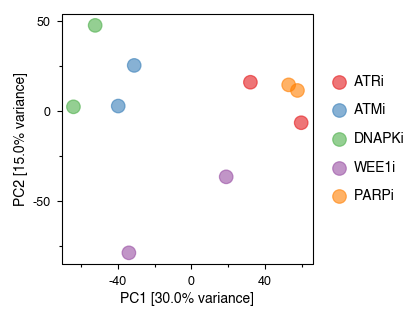

In [86]:
%matplotlib inline
ggplot_pca(crispri_v2_screen_pdata_mono, figure_size=(4,3), palette='Set1').draw()

This plot used for Fig. 1-B but ignored for the final manuscript.

In [87]:
# ggplot_pca(crispri_v2_screen_pdata_mono, figure_size=(4,3), palette='Set1').save('../plots/Fig-1B.pdf', width=4, height=3)

___

PCA for CRISPRi v2 screens (rho values) for all treatments

In [12]:
crispri_v2_screen_pdata.obs['treatment'] = pd.Categorical(crispri_v2_screen_pdata.obs['treatment'], categories=[
    'ATRi',
    'PARPi+ATRi',
    'ATMi',
    'PARPi+ATMi',
    'DNAPKi',
    'PARPi+DNAPKi',
    'WEE1i',
    'PARPi+WEE1i',
    'PARPi',
])

In [89]:
sc.pp.regress_out(crispri_v2_screen_pdata, ['replicate'])

In [90]:
sc.pp.pca(crispri_v2_screen_pdata)

___

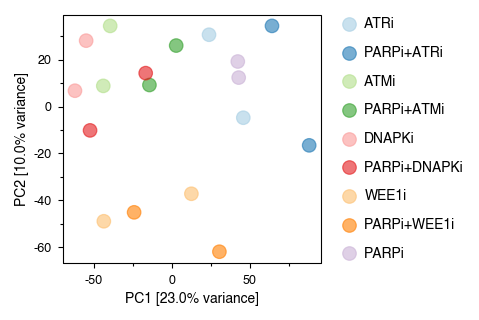

In [91]:
%matplotlib inline
ggplot_pca(crispri_v2_screen_pdata, figure_size=(4.6,3), palette='Paired').draw()

In [92]:
ggplot_pca(crispri_v2_screen_pdata, figure_size=(4.6,3), palette='Paired').save(
    '../plots/A549__CRISPRi_v2__PCA_plot.pdf',
    width=4.6, height=3)

/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 4.6 x 3 in image.
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../plots/A549__CRISPRi_v2__PCA_plot.pdf
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


In [93]:
# with plt.rc_context():  # Use this to set figure params like size and dpi
#     sc.pl.pca(crispri_v2_screen_pdata,size=400, color='treatment', palette='tab20c', frameon=True, show=False)
#     plt.savefig("plots/Fig-2A.pdf", bbox_inches="tight",format='pdf')

___

#### CRISPRa

In [13]:
crispra_v2_screen.buildPhenotypeData(run_name='compare_reps', db_rate_col=None)

crispra_v2_screen.pdata.obs['replicate'] = crispra_v2_screen.pdata.obs.index.str[-1]#.astype(int)
crispra_v2_screen.pdata.obs['score_tag'] = crispra_v2_screen.pdata.obs.index.str.split('::').str[0].str.split(':').str[0]
crispra_v2_screen.pdata.obs['comparison'] = crispra_v2_screen.pdata.obs.index.str.split('::').str[0].str.split(':').str[1]

In [14]:
crispra_v2_screen_pdata = crispra_v2_screen.pdata[crispra_v2_screen.pdata.obs.score_tag.isin(['rho'])].copy()
crispra_v2_screen_pdata.obs['treatment'] = crispra_v2_screen_pdata.obs['comparison'].apply(lambda x: drug_names[x.replace('_vs_DMSO','')]).to_list()

PCA for CRISPRa v2 screens (rho values) for all treatments

In [96]:
crispra_v2_screen_pdata.obs

,replicate,score_tag,comparison,treatment
rho:Pi_vs_DMSO::replicate_1,1,rho,Pi_vs_DMSO,PARPi
rho:Ri_vs_DMSO::replicate_1,1,rho,Ri_vs_DMSO,ATRi
rho:PiRi_vs_DMSO::replicate_1,1,rho,PiRi_vs_DMSO,PARPi+ATRi
rho:Wi_vs_DMSO::replicate_1,1,rho,Wi_vs_DMSO,WEE1i
rho:PiWi_vs_DMSO::replicate_1,1,rho,PiWi_vs_DMSO,PARPi+WEE1i


In [15]:
crispra_v2_screen_pdata.obs['treatment'] = pd.Categorical(crispra_v2_screen_pdata.obs['treatment'], categories=[
    'ATRi',
    'PARPi+ATRi',
    'WEE1i',
    'PARPi+WEE1i',
    'PARPi',
])

In [16]:
# sc.pp.regress_out(crispra_v2_screen_pdata, ['replicate'])

In [99]:
sc.pp.pca(crispra_v2_screen_pdata)

---

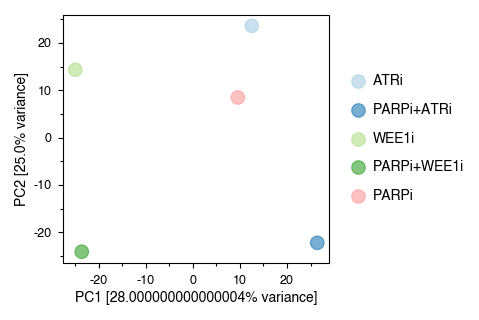

In [100]:
%matplotlib inline
ggplot_pca(crispra_v2_screen_pdata, figure_size=(4.6,3), palette='Paired').draw()

In [101]:
ggplot_pca(crispra_v2_screen_pdata, figure_size=(4.6,3), palette='Paired').save(
    '../plots/A549__CRISPRa_v2__PCA_plot.pdf',
    width=4.6, height=3
)

/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 4.6 x 3 in image.
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../plots/A549__CRISPRa_v2__PCA_plot.pdf
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


### Scatter plots

In [17]:
def plot_score_scatters(screen, title, untreated='vehicle', treated='DNAPKi'):
    fig, axes = plt.subplots(ncols=3,
                             figsize=(6.2,3), 
                             gridspec_kw={'wspace': 0.4, 'left': 0.12,'top':.8,'bottom':.3}, 
                             # sharey=True
                            )
    
    scp.pl.plotReplicateScatter(axes[0], screen.pdata,
                                f'gamma:{untreated}_vs_T0::replicate_1',
                                f'gamma:{untreated}_vs_T0::replicate_2',
                                title='gamma',
                                 # min_val=-1,max_val=1,
                                 log_transform=False)
    scp.pl.plotReplicateScatter(axes[1], screen.pdata,
                                f'tau:{treated}_vs_T0::replicate_1',
                                f'tau:{treated}_vs_T0::replicate_2',
                                title='tau',
                                 # min_val=-1,max_val=1,
                                 log_transform=False)
    scp.pl.plotReplicateScatter(axes[2], screen.pdata,
                                f'rho:{treated}_vs_{untreated}::replicate_1',
                                f'rho:{treated}_vs_{untreated}::replicate_2',
                                title='rho',
                                 # min_val=-1,max_val=1,
                                 log_transform=False)
    
    
    for ax in axes: 
        ax.tick_params(width=0.5)
        for i in ax.spines.values(): i.set_linewidth(0.5)
        # ax.spines['top'].set_visible(False)
        # ax.spines['right'].set_visible(False)
        # ax.spines['bottom'].set_visible(False)
        # ax.spines['left'].set_visible(False)
        for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
            item.set_fontsize(8)
        for item in ax.get_xticklabels() + ax.get_yticklabels():
            item.set_fontsize(6)
        
        # ax.set_xticks(list(map(lambda x: x/10.0, range(-10, 11, 5))))
        # ax.set_xticks(list(map(lambda x: x/10.0, range(-10, 11, 5))))
    
    fig.suptitle(title,fontsize=12)
    
    return fig

draw scatter plots

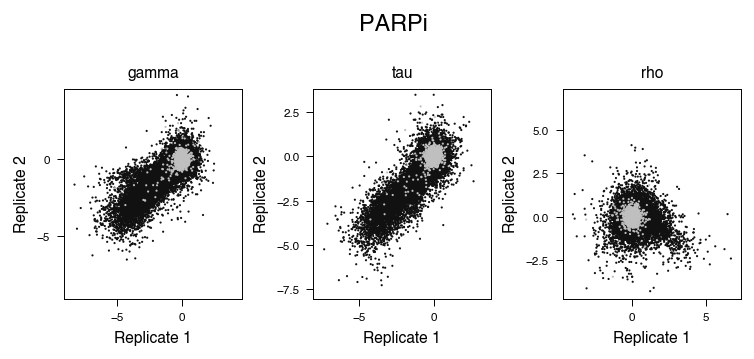

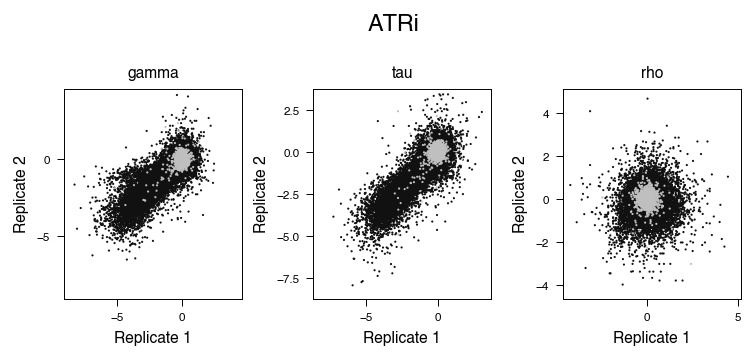

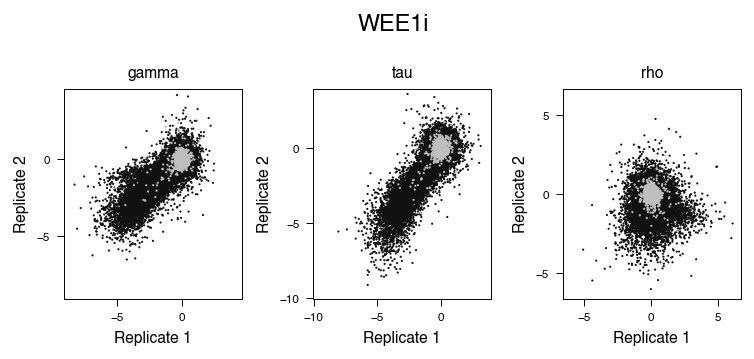

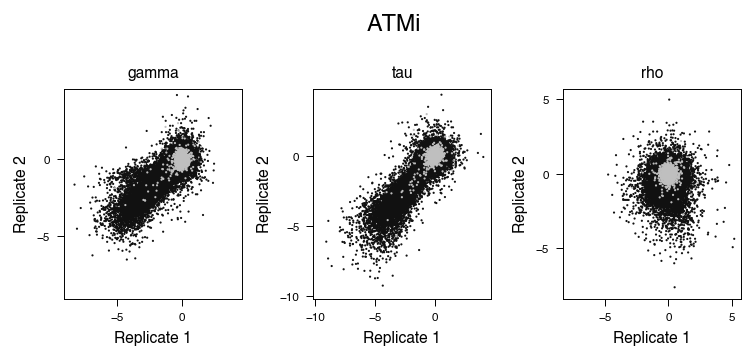

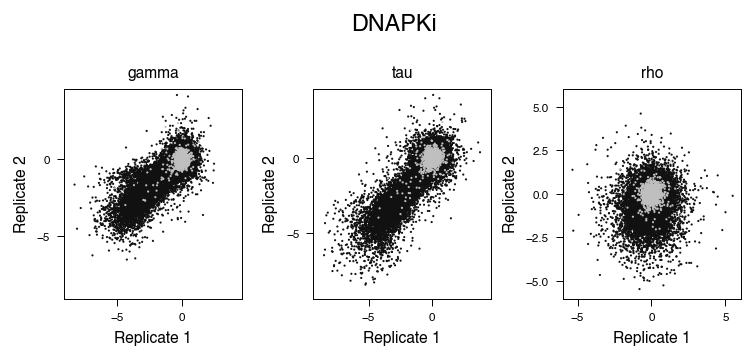

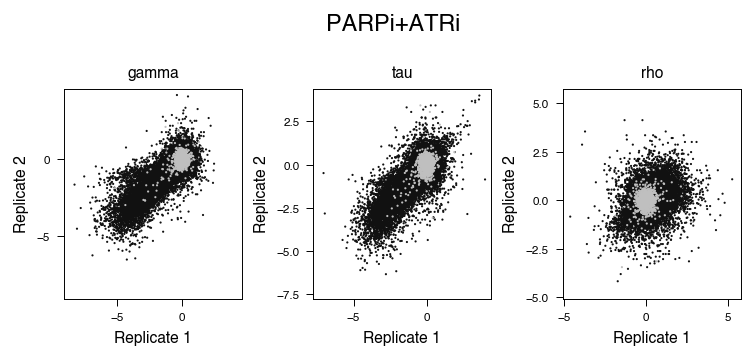

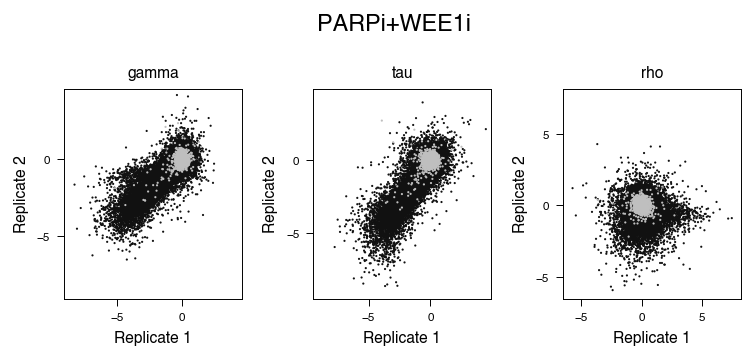

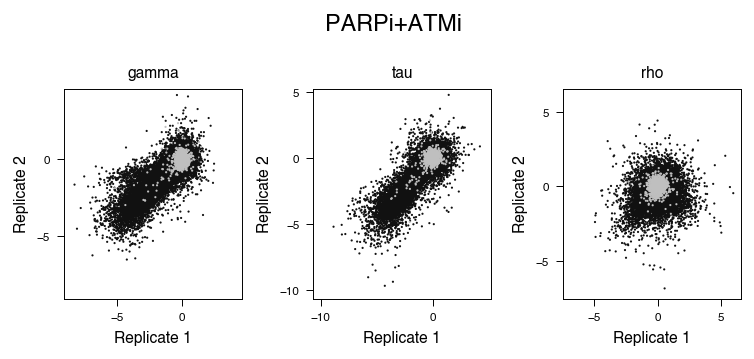

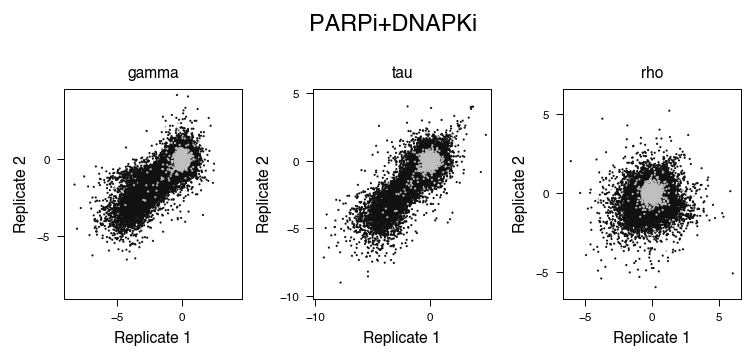

In [36]:
figs_score_scatters = {}

for drug_id, drug_name in drug_names.items():
    if drug_name != 'DMSO':
        figs_score_scatters[drug_name] = plot_score_scatters(
            crispri_v2_screen, drug_name, untreated='DMSO', treated=drug_id
        )

save plots 

In [37]:
with PdfPages('../plots/A549__CRISPRi_v2__score_scatter_plots.pdf') as pdf:

    for fig in figs_score_scatters.values():
        # Save the plot as a PDF
        pdf.savefig(fig, dpi=500)  # saves the current figure into a pdf page

    d = pdf.infodict()
    d['Title'] = 'ScreenPro2 plots'
    d['ModDate'] = datetime.datetime.today()

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


### Rank plots

In [38]:
def draw_rank_plot(df, col, ax, sen_hits, q_thr=0.05):
    
    _, _ = scp.pl._rank.rank_plot(
        df,
        col,
        ylabel='',
        highlight_values_dict={
            # '#3182bd': {
            '#482677': {
                'genes': sen_hits,
                'text': True
            },
        },
        ax=ax,
        highlight_size_factor=10,
        dot_size=.05,
        txt_font_size=6,
        title=col,
        # rasterized=True,
    )
    
    ax.set_xlim(-1000,21000)
    ax.set_xticks(np.arange(0, 20001, 5000))

    ax.tick_params(width=.5)
    for i in ax.spines.values(): i.set_linewidth(.5)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.spines['bottom'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    for item in ([ax.title]):
        item.set_fontsize(9)
    for item in ([ax.xaxis.label, ax.yaxis.label]):
        item.set_fontsize(6)
    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontsize(6)
    
    # ax.hlines(df[col].quantile(q=q_thr), 0, 1, transform=ax.get_yaxis_transform(), linewidth=1, linestyles='-', colors='#3182bd')
    # ax.hlines(df[col].quantile(q=1-q_thr), 0, 1, transform=ax.get_yaxis_transform(), linewidth=1, linestyles='-', colors='#de2d26')

___

In [647]:
hits_common_sen = ['CDK12', 'MCPH1', 'PRDX1', 'RAD9A', 'RFC5', 'XRCC3']

In [648]:
label_sen_hits = {
    'PARPi': ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
    'ATRi':  ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
    'ATMi':  ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
    'WEE1i': ['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1','PKMYT1'] + hits_common_sen,
    'DNAPKi':['RNF8','XRCC2','RBBP8','BRCA1','RAD51D','MDC1','LIG1'] + hits_common_sen,
}
# drop duplicates
for k in label_sen_hits.keys():
    label_sen_hits[k] = list(set(label_sen_hits[k]))

In [28]:
result_tables = crispri_v2_screen_result_tables

/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1351: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ign

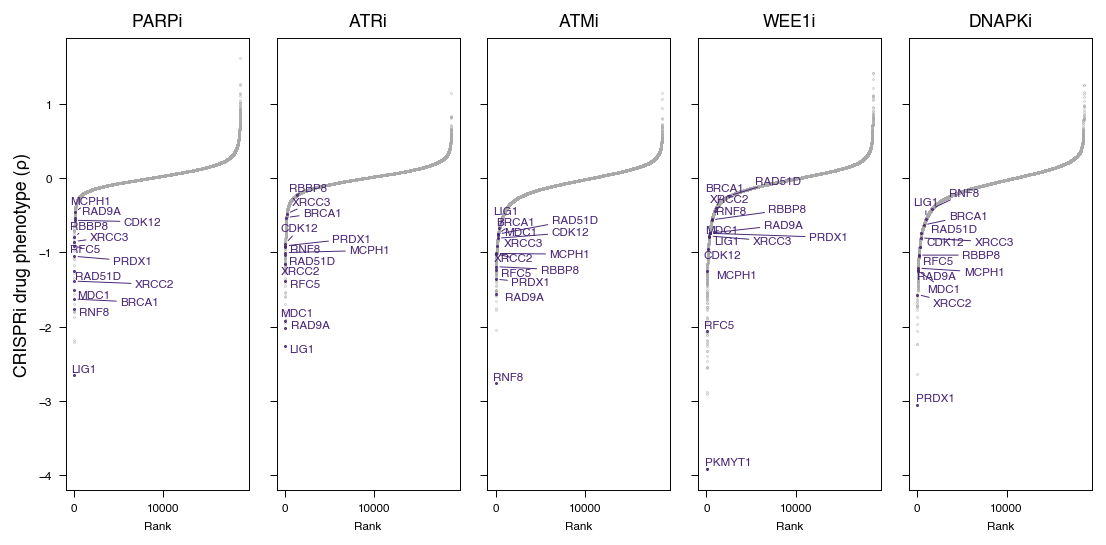

In [29]:
%matplotlib inline
fig, axes = plt.subplots(1,5,figsize=(8, 4), sharey=True)

i = 0

for res_name in result_tables.columns.get_level_values(0).unique():
    if 'rho' in res_name:
        treatment = res_name.split(':')[1].split('_vs_')[0]
        if '+' not in treatment:
            ax = axes[i]
            draw_rank_plot(
                result_tables[res_name].query('target!="negative_control"'),
                'score', 
                ax,
                sen_hits=label_sen_hits[treatment]
            )
            ax.set_title(treatment,fontsize=9)
            i=i+1


axes[0].set_ylabel('CRISPRi drug phenotype (ρ)', fontsize=9)

# Save the plot as a PDF
fig.tight_layout()
plt.savefig('../plots/A549__CRISPRi_v2__rho_rank_plots_mono.pdf', bbox_inches='tight', format='pdf')

### Gene level volcano and scatter plots

In [144]:
# matrix of rho scores
rho_mat = crispri_v2_screen_result_tables.xs('score', level=1, axis=1).filter(like='rho', axis=1)
rho_mat.columns = rho_mat.columns.str.split(':').str[1].str.split('_vs_').str[0]
# add targetType column, if pseudo in index, set targetType to 'negative_control'
rho_mat['targetType'] = np.where(rho_mat.index.str.contains('pseudo'), 'negative_control', 'gene')

In [162]:
rho_mat.drop(columns=['targetType']).min().min()

np.float64(-4.007229885610682)

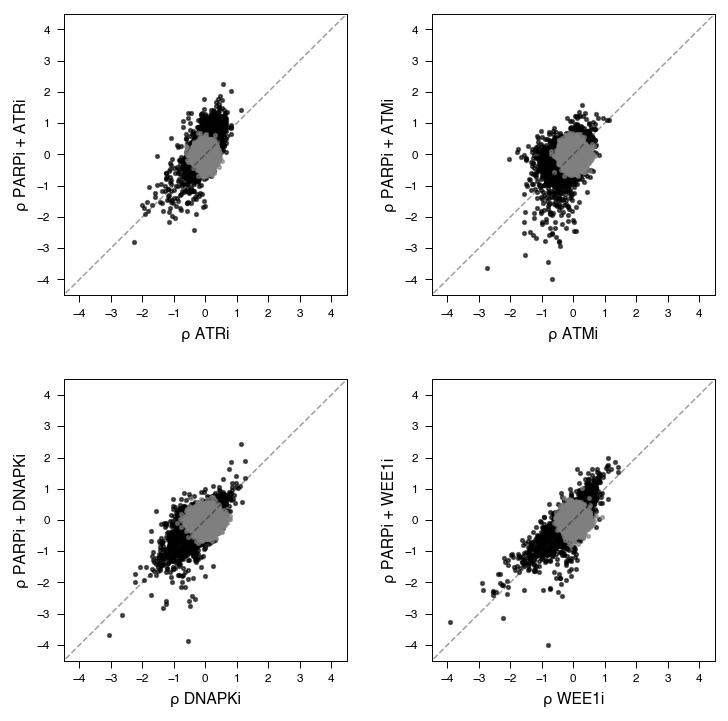

In [171]:
fig, axes = plt.subplots(2,2,figsize=(6,6), gridspec_kw={'wspace': 0.3, 'hspace':0.3})
treatments = ['ATRi', 'ATMi', 'DNAPKi', 'WEE1i']
colors = {'gene': 'black', 'negative_control': 'gray'}  # Define colors for target types

for i, treatment in enumerate(treatments):
    ax = axes[i//2, i%2]

    # Scatter plot with color based on targetType
    for target_type in rho_mat['targetType'].unique():
        ax.scatter(
            rho_mat[rho_mat['targetType'] == target_type][treatment],
            rho_mat[rho_mat['targetType'] == target_type]['PARPi+'+treatment],
            s=3,
            alpha=0.6,
            color=colors[target_type],
            label=target_type if i == 0 else ""  # Only add label for the first subplot
        )
    
    ax.plot(
        [-5,5],
        [-5,5],
        color=almost_black,
        linestyle='--',
        alpha=0.4,
        linewidth=0.8
    )
    ax.set_xlabel(f'ρ {treatment}', fontsize=9)
    ax.set_ylabel(f'ρ PARPi + {treatment}', fontsize=9)
    ax.tick_params(width=0.5)
    for spine in ax.spines.values(): spine.set_linewidth(0.5)
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
        item.set_fontsize(8)
    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontsize(6)
    ax.set_xlim(-4.5,4.5)
    ax.set_ylim(-4.5,4.5)
    
    # set major ticks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

/tmp/ipykernel_2663726/3779017598.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


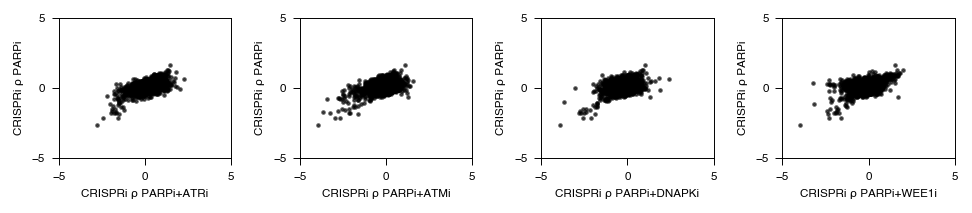

In [131]:
%matplotlib inline
# scatter plot of PARPi vs all combinations

fig, axes = plt.subplots(1,4,figsize=(8, 2), gridspec_kw={'wspace': 0.4, 'left':.1,'top':.8,'bottom':.3})

treatments_combo = ['PARPi+ATRi', 'PARPi+ATMi', 'PARPi+DNAPKi', 'PARPi+WEE1i']

for i, treatment in enumerate(treatments_combo):
    ax = axes[i]
    ax.scatter(
        rho_mat[treatment],
        rho_mat['PARPi'],
        s=2,
        alpha=0.6,
        color='black'
    )
    ax.set_xlabel(f'CRISPRi ρ {treatment}', fontsize=9)
    ax.set_ylabel('CRISPRi ρ PARPi', fontsize=9)
    ax.tick_params(width=.5)
    for item in ([ax.title]):
        item.set_fontsize(9)
    for item in ([ax.xaxis.label, ax.yaxis.label]):
        item.set_fontsize(6)
    for item in ax.get_xticklabels() + ax.get_yticklabels():
        item.set_fontsize(6)
    for i in ax.spines.values(): i.set_linewidth(.5)
    ax.set_xlim(-5,5)
    ax.set_ylim(-5,5)

fig.tight_layout()
plt.show()    

### Pathway analysis

run gsea

gamma:DMSO_vs_T0                                            \
                       target         transcript     score ttest pvalue   
A1BG                     A1BG                 P1 -0.192019     0.461940   
A1CF                     A1CF               P1P2  0.093319     0.500301   
A2M                       A2M               P1P2 -0.055924     0.815631   
A2ML1                   A2ML1               P1P2  0.072751     0.574093   
A3GALT2               A3GALT2  ENST00000442999.3 -0.051686     0.949523   
...                       ...                ...       ...          ...   
pseudo_9975  negative_control                 na -0.018837     0.633597   
pseudo_9980  negative_control                 na -0.162741     0.250234   
pseudo_9985  negative_control                 na  0.116725     0.121457   
pseudo_9990  negative_control                 na -0.166340     0.426884   
pseudo_9995  negative_control                 na -0.167797     0.481558   

                                                                   \
            BH adj_pvalue number_of_guide_elements combined_score   
A1BG             0.772360                        3      -0.290331   
A1CF             0.793265                        3       0.126524   
A2M              0.938280                        3      -0.022312   
A2ML1            0.831979                        3       0.079042   
A3GALT2          0.985710                        3      -0.005241   
...                   ...                      ...            ...   
pseudo_9975      0.860033                        3      -0.016829   
pseudo_9980      0.641439                        3      -0.441380   
pseudo_9985      0.542112                        3       0.481756   
pseudo_9990      0.752342                        3      -0.277206   
pseudo_9995      0.782510                        3      -0.240045   

                              rho:PARPi_vs_DMSO                     ...  \
                        label            target         transcript  ...   
A1BG           target_non_hit              A1BG                 P1  ...   
A1CF           target_non_hit              A1CF               P1P2  ...   
A2M            target_non_hit               A2M               P1P2  ...   
A2ML1          target_non_hit             A2ML1               P1P2  ...   
A3GALT2        target_non_hit           A3GALT2  ENST00000442999.3  ...   
...                       ...               ...                ...  ...   
pseudo_9975  negative_control  negative_control                 na  ...   
pseudo_9980  negative_control  negative_control                 na  ...   
pseudo_9985  negative_control  negative_control                 na  ...   
pseudo_9990  negative_control  negative_control                 na  ...   
pseudo_9995  negative_control  negative_control                 na  ...   

            rho:DNAPKi_vs_DMSO                   rho:PARPi+DNAPKi_vs_DMSO  \
                combined_score             label                   target   
A1BG              3.576746e-01    target_non_hit                     A1BG   
A1CF              5.161979e-02    target_non_hit                     A1CF   
A2M              -2.332918e-02    target_non_hit                      A2M   
A2ML1            -2.988461e-01    target_non_hit                    A2ML1   
A3GALT2          -6.524956e-01    target_non_hit                  A3GALT2   
...                        ...               ...                      ...   
pseudo_9975      -1.330954e+00  negative_control         negative_control   
pseudo_9980       1.325113e+00  negative_control         negative_control   
pseudo_9985      -4.264361e-07  negative_control         negative_control   
pseudo_9990      -1.001465e+00  negative_control         negative_control   
pseudo_9995       3.362528e-01  negative_control         negative_control   

                                                                     \
                    transcript     score ttest pvalue BH adj_pvalue   
A1BG               

In [616]:
crispra_v2_screen_gsea_results = {}

for drug_name in crispra_v2_screen_result_tables.columns.get_level_values(0).unique():

    if 'gamma' not in drug_name:
        
        print(drug_name)
        
        _, res = run_rho_gsea_directional(
            crispra_v2_screen_result_tables[drug_name], 
            var_col='score',
            gmt=c5_gobp_gmt,
            # min_size=150,
            # max_size=np.inf
        )

        crispra_v2_screen_gsea_results[drug_name] = res

rho:PARPi_vs_DMSO
Use cached anchor parameters


Enrichment : 100%|██████████| 7481/7481 [00:02<00:00, 2545.68it/s]
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/statsmodels/stats/multitest.py:164: RuntimeWarning: divide by zero encountered in log1p


rho:ATRi_vs_DMSO
Use cached anchor parameters


Enrichment : 100%|██████████| 7481/7481 [00:02<00:00, 2503.87it/s]
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/statsmodels/stats/multitest.py:164: RuntimeWarning: divide by zero encountered in log1p


rho:PARPi+ATRi_vs_DMSO
Use cached anchor parameters


Enrichment : 100%|██████████| 7481/7481 [00:02<00:00, 2612.68it/s]
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/statsmodels/stats/multitest.py:164: RuntimeWarning: divide by zero encountered in log1p


rho:WEE1i_vs_DMSO
Use cached anchor parameters


Enrichment : 100%|██████████| 7481/7481 [00:02<00:00, 2562.60it/s]
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/statsmodels/stats/multitest.py:164: RuntimeWarning: divide by zero encountered in log1p


rho:PARPi+WEE1i_vs_DMSO
Use cached anchor parameters


Enrichment : 100%|██████████| 7481/7481 [00:02<00:00, 2548.67it/s]
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/statsmodels/stats/multitest.py:164: RuntimeWarning: divide by zero encountered in log1p


In [21]:
crispri_v2_screen_gsea_results = {}

for drug_name in crispri_v2_screen_result_tables.columns.get_level_values(0).unique():

    if 'gamma' not in drug_name:
        
        print(drug_name)

        _, res = run_rho_gsea_directional(
            crispri_v2_screen_result_tables[drug_name], 
            var_col='score', 
            gmt=c5_gobp_gmt,
            # min_size=150,
            # max_size=np.inf
        )

        crispri_v2_screen_gsea_results[drug_name] = res

rho:PARPi_vs_DMSO


Enrichment : 100%|██████████| 7481/7481 [00:03<00:00, 2467.02it/s]
/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/statsmodels/stats/multitest.py:164: RuntimeWarning: divide by zero encountered in log1p


rho:ATRi_vs_DMSO


Enrichment : 100%|██████████| 7481/7481 [00:02<00:00, 2619.47it/s]


rho:PARPi+ATRi_vs_DMSO


...

Enrichment : 100%|██████████| 7481/7481 [00:02<00:00, 2542.10it/s]


rho:DNAPKi_vs_DMSO


Enrichment : 100%|██████████| 7481/7481 [00:03<00:00, 2353.20it/s]


rho:PARPi+DNAPKi_vs_DMSO


Enrichment : 100%|██████████| 7481/7481 [00:03<00:00, 2433.34it/s]


#### Build AnnData from pathway analysis results

In [24]:
def format_gsea_term_names(df_in):
    df = df_in.copy()
    df.index = df.index.str.replace('GOBP_','').str.replace('_',' ').str.lower()

    for word in ['dna', 'rna',' i ', ' ii ', 'nadh', 'atp']:
        df.index = df.index.str.replace(word,word.upper())

    return df


def anndata_from_gsea_results(gsea_results):

    gsea_results = dict([(k,v) for k,v in crispri_v2_screen_gsea_results.items()])
    gsea_df = pd.concat(gsea_results).reset_index(names=['signature','term'])
    gsea_df.drop_duplicates(subset=['signature','leading_edge'], inplace=True) # remove duplicated leading edges
    gsea_df['-log10(FDR)'] = -np.log10(gsea_df['fdr']).replace(np.inf, np.nan).replace(-np.inf, np.nan)
    gsea_df['nes'] = gsea_df['nes'].replace(np.inf, np.nan).replace(-np.inf, np.nan)
    gsea_df['fdr'] = gsea_df['fdr'].replace(np.inf, np.nan).replace(-np.inf, np.nan)
    gsea_df.dropna(subset=['nes','fdr'], inplace=True)

    nes_mat = gsea_df.pivot(index='term', columns='signature', values='nes').T
    pv_mat = gsea_df.pivot(index='term', columns='signature', values='fdr').T

    adata = ad.AnnData(nes_mat)
    adata.layers['fdr'] = pv_mat.values
    adata.layers['nes'] = nes_mat.values

    return adata, gsea_df

In [25]:
gsea_adata, gsea_df = anndata_from_gsea_results(crispri_v2_screen_gsea_results)
gsea_adata.obs['treatment'] = gsea_adata.obs.index.str.split(':').str[1].str.split('_vs_').str[0]
gsea_adata.obs['is_combo'] = gsea_adata.obs['treatment'].str.contains(r'\+')

/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


In [26]:
gsea_adata_mono = gsea_adata[~gsea_adata.obs['is_combo']].copy()

### Hierarchical clustering of GO terms

In [27]:
import PyComplexHeatmap as pch

---

In [102]:
crispri_v2_screen_pdata

AnnData object with n_obs × n_vars = 18 × 101133
    obs: 'replicate', 'score_tag', 'comparison', 'treatment'
    var: 'target', 'protospacer', 'sequence', 'targetType', 'transcript', 'low_count'

In [ ]:
%matplotlib inline
plt.figure(figsize=(3, 5.5))

d = gsea_adata[:,gsea_adata.to_df(layer='fdr').T.le(0.1).sum(axis=1).gt(0)].to_df(layer='nes').T
d.columns = gsea_adata.obs['treatment']

cm = pch.ClusterMapPlotter(
    format_gsea_term_names(d),
    row_cluster=True,
    row_dendrogram=True,
    col_cluster=True,
    col_dendrogram=True,
    show_colnames=True,
    show_rownames=False,
    cmap='RdBu_r',
    center=0,
    vmax=10,
    vmin=-10,
)

Starting..
Calculating row orders..
Reordering rows..


/khayyam/abe/miniconda3/envs/screenpro2/lib/python3.12/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.


Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 7.5 mm


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


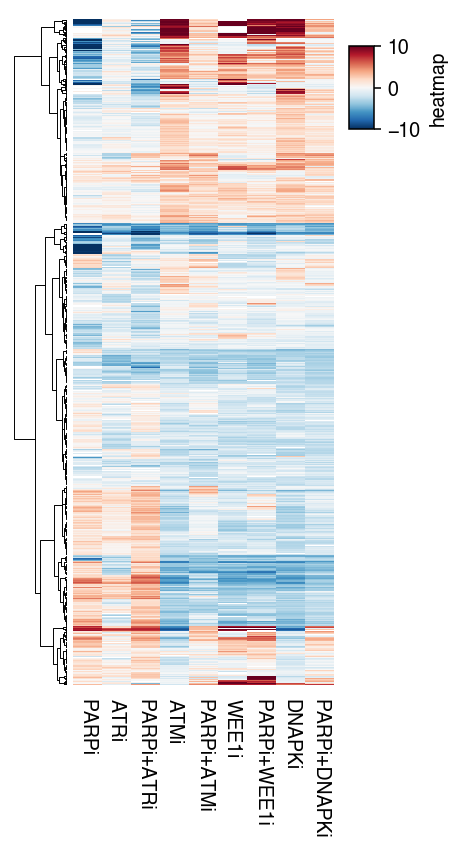

In [176]:
%matplotlib inline
plt.figure(figsize=(3, 5.5))

d = gsea_adata[:,gsea_adata.to_df(layer='fdr').T.le(0.2).sum(axis=1).gt(0)].to_df(layer='nes').T
d.columns = gsea_adata.obs['treatment']
d = d[
    [
        'PARPi',
        'ATRi','PARPi+ATRi',
        'ATMi','PARPi+ATMi',
        'WEE1i','PARPi+WEE1i',
        'DNAPKi','PARPi+DNAPKi',
    ]
]


cm = pch.ClusterMapPlotter(
    format_gsea_term_names(d),
    row_cluster=True,
    row_dendrogram=True,
    col_cluster=False,
    show_colnames=True,
    show_rownames=False,
    cmap='RdBu_r',
    center=0,
    vmax=10,
    vmin=-10,
)

plt.savefig('../plots/A549__CRISPRi_v2__GSEA_heatmap_plot_full.pdf', bbox_inches='tight', format='pdf')

In [83]:
# fig = plt.figure()

# # make dict
# d_top = gsea_adata.to_df(layer='fdr').le(0.1).T
# d_top.columns = gsea_adata.obs['treatment']

# u = up.UpSet(
#     d_top.reset_index().set_index(d_top.columns.to_list()),
#     subset_size='count',
#     show_counts='%d',
#     sort_by='cardinality',
#     min_degree=9
# )

# u.style_subsets(
#     max_degree = 10,
#     facecolor = 'grey',
# )

# u.style_subsets(
#     # present="PARPi",
#     min_degree = 9 ,
#     # absent="cat1", 
#     facecolor="lightblue",
#     edgecolor="darkgreen",
#     linewidth=2
# )

# u.plot(fig = fig)

# plt.show()

---

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 7.5 mm


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


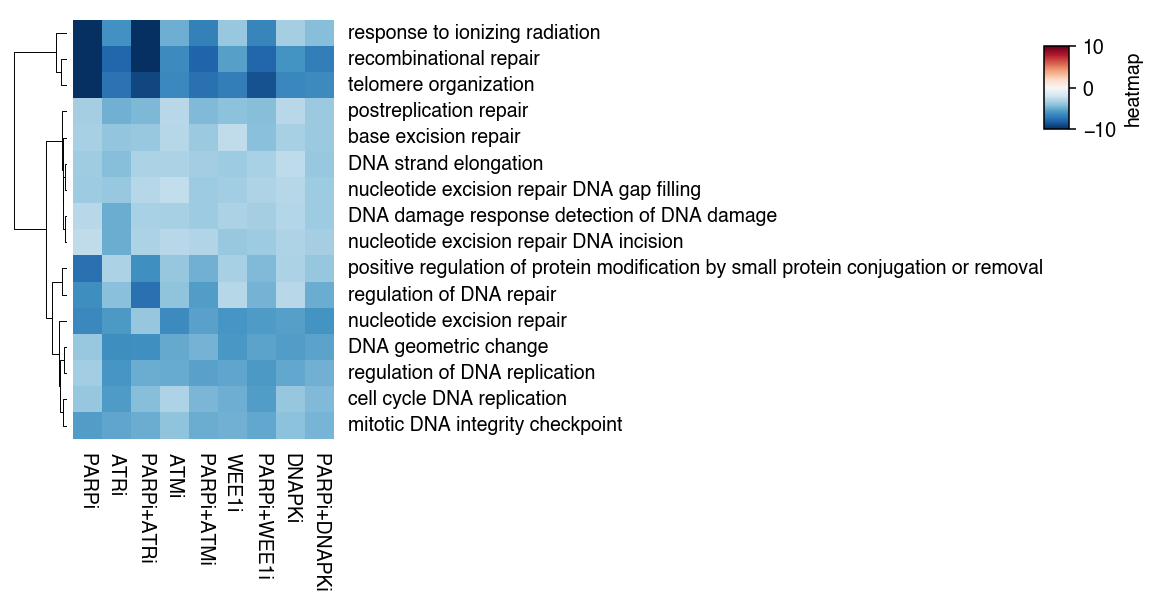

In [182]:
plt.figure(figsize=(3, 3.5))

d = gsea_adata[
    :,
    (gsea_adata.to_df(layer='fdr').T.le(0.2).sum(axis=1).eq(9) & gsea_adata.to_df(layer='nes').T.le(0).sum(axis=1).eq(9))
].to_df(layer='nes').T
d.columns = gsea_adata.obs['treatment']
d = d[
    [
        'PARPi',
        'ATRi','PARPi+ATRi',
        'ATMi','PARPi+ATMi',
        'WEE1i','PARPi+WEE1i',
        'DNAPKi','PARPi+DNAPKi',
    ]
]

cm = pch.ClusterMapPlotter(
    format_gsea_term_names(d),
    row_cluster=True,
    row_dendrogram=True,
    col_cluster=False,
    # col_dendrogram=True,
    show_colnames=True,
    show_rownames=True,
    cmap='RdBu_r',
    center=0,
    vmax=10,
    vmin=-10,
)

plt.savefig('../plots/A549__CRISPRi_v2__GSEA_heatmap_plot.pdf', bbox_inches='tight', format='pdf')

#### Dotplot for enriched pathways

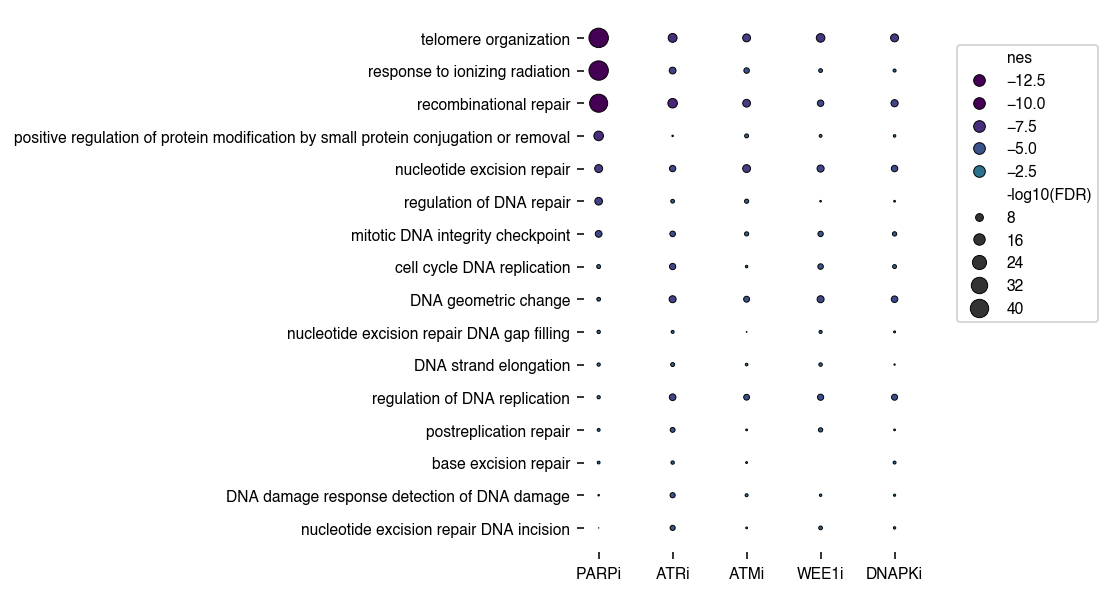

In [95]:
%matplotlib inline
# Set the figure size and style
fig, ax = plt.subplots(figsize=(3, 5))

df = gsea_df.query(f'term.isin({list(d.index)}) & ~signature.isin({list(gsea_adata.obs[gsea_adata.obs["is_combo"]].index)})').set_index('term').copy()
df = format_gsea_term_names(df)
df.reset_index(inplace=True)
df['treatment'] = df['signature'].str.split(':').str[1].str.split('_vs_').str[0]
df
# Create the dot plot
scatter = sns.scatterplot(
    df,
    x='treatment',
    y='term',
    size='-log10(FDR)',
    hue='nes',
    hue_norm=matplotlib.colors.Normalize(vmin=-10, vmax=10),
    # palette=yellow_blue,#'viridis',
    palette='viridis',
    sizes=(0, 100),
    # alpha=0.7,
    edgecolor='k',
    linewidth=.5,
    ax = ax
)

# Improve the aesthetics
plt.xlabel(None)
plt.ylabel(None)

# Customize the legend
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=2., fontsize=8)

plt.box(False)

for item in ([ax.xaxis.label, ax.yaxis.label]):
    item.set_fontsize(8)
for item in ax.get_xticklabels() + ax.get_yticklabels():
    item.set_fontsize(8)

# Show the plot
# plt.savefig('../plots/A549__CRISPRi_v2__GSEA_dot_plot.pdf', bbox_inches='tight', format='pdf')
plt.show()

### UpSet plot

In [458]:
def get_hits_upset(result_tables):
    hits_dict = dict()

    # get level 0 column names
    for res_name in result_tables.columns.get_level_values(0).unique():
        if 'rho' in res_name:
            drug_name = res_name.split(':')[1].split('_vs_')[0]
            res = result_tables[res_name].query('target!="negative_control"').set_index('target')
            hits_dict[drug_name] = res[res['combined_score'].le(-6)].index.to_list()

    return hits_dict    

#### CRISPRi-v2 screens UpSet plots

mono treatments

<timed exec>:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


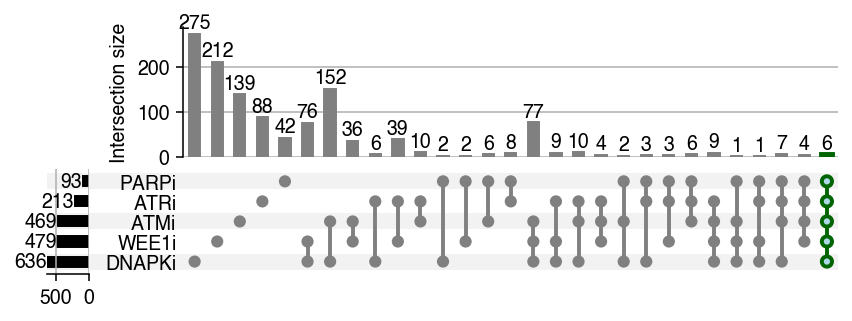

CPU times: user 494 ms, sys: 32.1 ms, total: 526 ms
Wall time: 524 ms


In [ ]:
%%time
fig = plt.figure()

hits_dict = get_hits_upset(crispri_v2_screen_result_tables)

u = up.UpSet(
    up.from_contents(
        dict([(treatment, hits) for treatment, hits in hits_dict.items() if '+' not in treatment])
    ),
    subset_size='count',
    sort_categories_by  = 'cardinality',
    # sort_by='cardinality',
    # orientation='vertiCil',
    show_counts='%d',
    other_dots_color=0.001, 
    min_degree=1,
    # min_subset_size = 4,
    element_size=15,
)

u.style_subsets(
    max_degree = 10,
    facecolor = 'grey',
)

u.style_subsets(
    # present="PARPi",
    min_degree = 5 ,
    # absent="cat1", 
    facecolor="lightblue",
    edgecolor="darkgreen",
    linewidth=2
)

# u.style_subsets(
#     # present="Pi dn", 
#     max_degree = 1 ,
#     # absent="cat1", 
#     facecolor="lightblue",
#     edgecolor="blue",
#     linewidth=2
# )
    
u.plot(fig = fig)
plt.tight_layout()
plt.savefig('../plots/A549__CRISPRi_v2__rho_hits_mono_upset_plot.pdf', bbox_inches='tight', format='pdf')
plt.show()

combo treatments

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


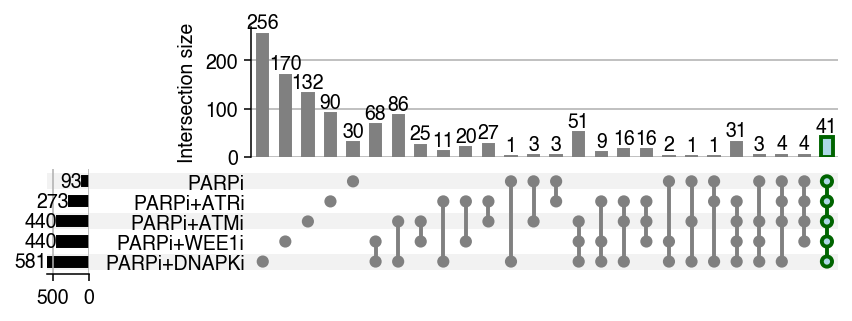

CPU times: user 751 ms, sys: 80.1 ms, total: 832 ms
Wall time: 827 ms


In [ ]:
%%time
fig = plt.figure()

hits_dict = get_hits_upset(crispri_v2_screen_result_tables)

u = up.UpSet(
    up.from_contents(
        dict([(treatment, hits) for treatment, hits in hits_dict.items() if 'PARPi' in treatment])
    ),
    subset_size='count',
    sort_categories_by  = 'cardinality',
    # sort_by='cardinality',
    # orientation='vertiCil',
    show_counts='%d',
    other_dots_color=0.001, 
    # shading_color=0, 
    # with_lines=False,
    min_degree=1,
    # min_subset_size = 4,
    element_size=15,
    
)

u.style_subsets(
    max_degree = 10,
    facecolor = 'grey',
)


u.style_subsets(
    # present="PARPi",
    min_degree = 5 ,
    # absent="cat1", 
    facecolor="lightblue",
    edgecolor="darkgreen",
    linewidth=2
)

u.plot(fig = fig)
                    
plt.savefig('../plots/A549__CRISPRi_v2__rho_hits_comb_upset_plot.pdf', bbox_inches='tight', format='pdf')

plt.show()

### spider plot

In [9]:
## Spider plot
# https://www.pythoncharts.com/matplotlib/radar-charts/

# Helper function to plot each ... on the radar chart.
def add_to_radar(ax, dft, target, color, angles, linewidth=1, alpha=0.1):
  values = dft.loc[target].tolist()
  values += values[:1]
  ax.plot(angles, values, color=color, linewidth=linewidth, label=target)
  ax.fill(angles, values, color=color, alpha=alpha)

def draw_radar(ax, dft, lims):
    num_vars = len(dft.columns)
    labels = dft.columns
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    theta = np.linspace(-np.pi / 2, np.pi / 2, 64 + 1)
    
    # The plot is a circle, so we need to "complete the loop"
    # and append the start value to the end.
    angles += angles[:1]

    # Fix axis to go in the right order and start at 12 o'clock.
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw axis lines for each angle and label.
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    
    # Make the y-axis labels smaller.
    ax.tick_params(axis='y', labelsize=8)
    
    # Set position of y-labels (0-100) to be in the middle
    # of the first two axes.
    ax.set_ylim(lims)
    ax.set_rlabel_position(180 / num_vars)
    
    # Go through labels and adjust alignment based on where
    # it is in the circle.
    for label, angle in zip(ax.get_xticklabels(), angles):
      if angle in (0, np.pi):
        label.set_horizontalalignment('center')
      elif 0 < angle < np.pi:
        label.set_horizontalalignment('left')
      else:
        label.set_horizontalalignment('right')

    return angles

---

In [10]:
def get_rho_score_matrix(result_tables, col):
    dfs = []
    # get level 0 column names
    for res_name in result_tables.columns.get_level_values(0).unique():
        if 'rho' in res_name:
            drug_name = res_name.split(':')[1].split('_vs_')[0]
            res = result_tables[res_name].query('target!="negative_control"').set_index('target')
            dfs.append(res[col].rename(drug_name))

    return pd.concat(dfs, axis=1)

In [12]:
score_df = get_rho_score_matrix(crispri_v2_screen_result_tables, 'score')

In [13]:
single_score_df = score_df.loc[:,~score_df.columns.str.contains('\+')]
combo_score_df = score_df.loc[:,score_df.columns.str.contains('PARPi')]

<>:1: SyntaxWarning: invalid escape sequence '\+'
<>:1: SyntaxWarning: invalid escape sequence '\+'
/tmp/ipykernel_2349568/471707405.py:1: SyntaxWarning: invalid escape sequence '\+'


In [15]:
hits_common_sen = [
    'CDK12', 'MCPH1', 'PRDX1', 'RAD9A', 'RFC5', 'XRCC3'
]

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


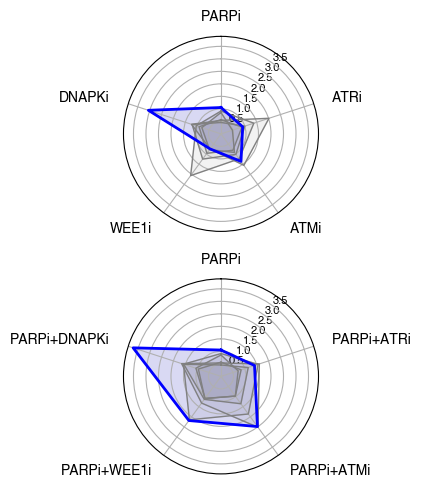

In [22]:
%matplotlib inline
fig, (ax,bx) = plt.subplots(2,1, figsize=(5, 5), subplot_kw=dict(polar=True), dpi=100)

angles = draw_radar(ax, single_score_df.abs(), lims = (0,3.9) )

for t in hits_common_sen:
    add_to_radar(ax, single_score_df.abs(), t, 'gray', angles)

add_to_radar(ax, single_score_df.abs(), 'PRDX1', 'b', angles, linewidth=2, alpha=.1)


angles = draw_radar(bx, combo_score_df.abs(), lims = (0,3.9) )

for t in hits_common_sen:
    add_to_radar(bx, combo_score_df.abs(), t, 'gray', angles)

add_to_radar(bx, combo_score_df.abs(), 'PRDX1', 'b', angles, linewidth=2, alpha=.1)

fig.tight_layout()
plt.savefig('../plots/A549__CRISPRi_v2__rho_spider_plot_common_sensitizers.pdf', bbox_inches='tight', format='pdf')

___

#### volcano plots

In [ ]:
# screen.listPhenotypeScores(run_name='compare_guides')#phenotypes['compare_guides']['results']

In [ ]:
# _, axes = plt.subplots(1,3,figsize=(9,3.5),dpi=200,sharey=True)


# for ax, treatment in zip(axes,['Pi','Ki','PiKi']):
#     crispri_v2_screen.drawVolcano(
#         run_name='compare_guides',
#         phenotype_name=f'rho:{treatment}_vs_DMSO', 
#         ax=ax, 
#         pvalue_col='ttest pvalue', 
#         threshold=6,
#         sensitivity_hits=['PRDX1'],
#         dot_size=4,
#         size_txt=9,
#         # ylims=[0,9],
#         # xlims=[-3,3],
#     )
#     ax.set_title(drug_names[treatment])


# for ax in axes: 
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.get_legend().remove()
#     ax.grid(False)

# plt.tight_layout()
# plt.show()

In [ ]:
# rho_PiKi = scp.ps.annotateScoreTable(
#     screen.phenotypes['compare_guides']['results']['rho:PiKi_vs_DMSO'],
#     up_hit=scp.ps._annotate.hit_dict['rho']['up_hit'],
#     down_hit=scp.ps._annotate.hit_dict['rho']['down_hit'],
#     threshold=6,
#     pvalue_col='ttest pvalue'
# )

# rho_PiKi.groupby('label').size()

#### get result tables

In [661]:
def getAnnotatedTables(screen, threshold):
    return dict([
        (phenotype_name, 
         screen.getPhenotypeScores(
             run_name='compare_guides',phenotype_name=phenotype_name,threshold=threshold, pvalue_col='ttest pvalue'
         ).query('target!="negative_control"').set_index(['target','transcript']))
        for phenotype_name in screen.listPhenotypeScores(run_name='compare_guides')
    ])

In [663]:
annotated_result_table = pd.concat(dict([
    (drug_names[k.split(':')[1].split('_vs_')[0]],table) for k, table in 
    getAnnotatedTables(crispri_v2_screen, threshold=6).items()
    if 'rho' in k
]),axis=1).dropna()

### A geneset!

In [673]:
rho_bin_CELL_REDOX_HOMEOSTASIS = get_rho_score_matrix(crispri_v2_screen_result_tables, 'combined_score').le(-6)
rho_bin_CELL_REDOX_HOMEOSTASIS = rho_bin_CELL_REDOX_HOMEOSTASIS.loc[list(set(c5_gobp_gmt['GOBP_CELL_REDOX_HOMEOSTASIS']) & set(rho_bin_CELL_REDOX_HOMEOSTASIS.index)),:]
rho_bin_CELL_REDOX_HOMEOSTASIS = rho_bin_CELL_REDOX_HOMEOSTASIS.loc[rho_bin_CELL_REDOX_HOMEOSTASIS.sum(axis=1).sort_values(ascending=False).index.to_list(),:]

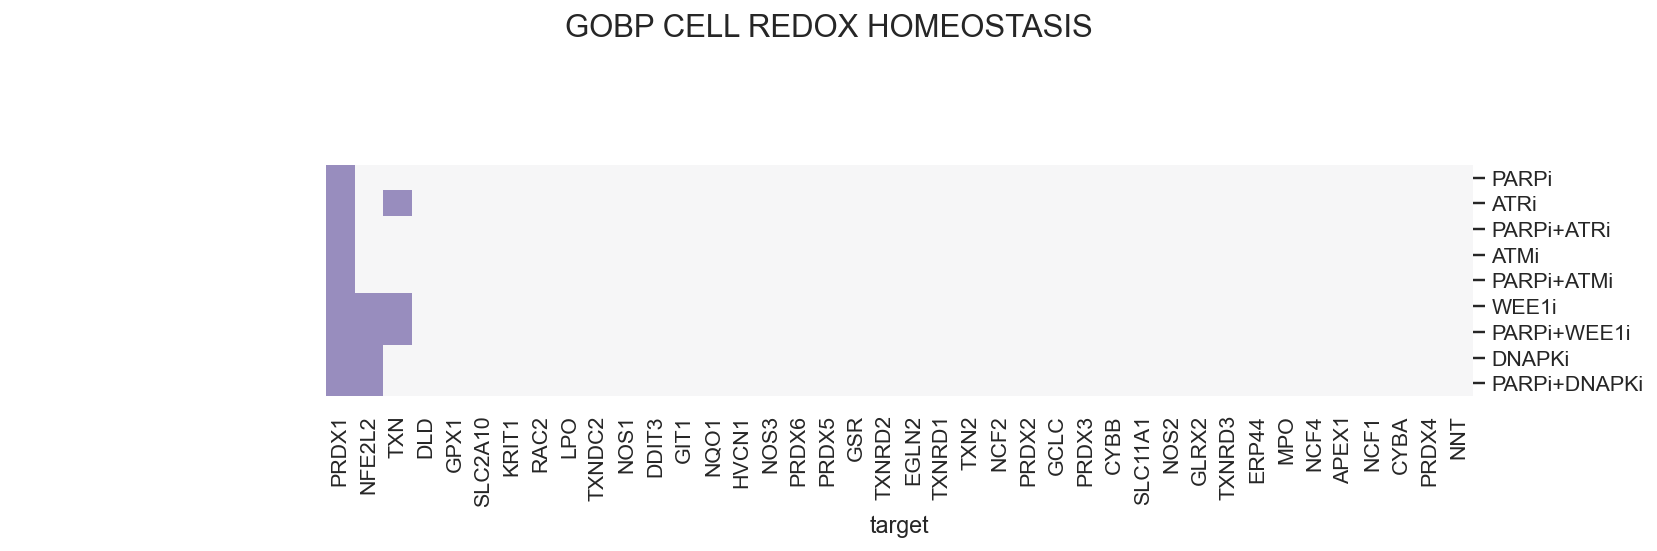

In [676]:
g = sns.clustermap(
    rho_bin_CELL_REDOX_HOMEOSTASIS.T,
    cmap='PuOr',#,#'RdBu_r',
    vmin=-2,
    vmax=2,
    row_cluster=False,
    col_cluster=False,
    # dendrogram_ratio=0.1,
    # cbar_kws={'shrink': .5},
    figsize=(12,4),
)

g.fig.suptitle('GOBP CELL REDOX HOMEOSTASIS',size=16) 
g.cax.set_visible(False)

g.ax_col_dendrogram.set_visible(False)

plt.tight_layout()
g.savefig('../plots/A549__CRISPRi_v2__rho_hits_gobp_cell_redox_homeostasis_bin_heatmap.pdf', bbox_inches='tight', format='pdf')
plt.show()

### save to file

? how we want to organize the results for the manuscript tables (!)

- Tom also asked for gamma scores.

In [677]:
# with pd.ExcelWriter('A549_CRISPRi_screen_analysis.xlsx', engine='openpyxl') as writer:
#     screen.adata.obs.to_excel(writer, sheet_name='sample sheet')
#     screen.adata.to_df(layer='raw_counts').astype(int).T.to_excel(writer, sheet_name='raw counts')
#     screen.adata.to_df(layer='seq_depth_norm').astype(int).T.to_excel(writer, sheet_name='normalized counts')
#     .to_excel(writer, sheet_name='guide-level scores')
#     annotated_result_table.to_excel(writer, sheet_name='gene-level scores')
#     pd.concat(gsea_results,axis=1).to_excel(writer, sheet_name='GSEA')

Table-S1

In [679]:
with pd.ExcelWriter('../tables/Table-S1.xlsx', engine='openpyxl') as writer:
    crispri_v2_screen_result_tables.to_excel(writer, sheet_name='Gene Level Phenotypes')
    pd.concat(crispri_v2_screen_gsea_results,axis=1).to_excel(writer, sheet_name='GO GSEA Analysis')

Table S2

In [680]:
with pd.ExcelWriter('../tables/Table-S2.xlsx', engine='openpyxl') as writer:
    crispra_v2_screen_result_tables.to_excel(writer, sheet_name='Gene Level Phenotypes')
    pd.concat(crispra_v2_screen_gsea_results,axis=1).to_excel(writer, sheet_name='GO GSEA Analysis')

___

# 

In [681]:
%reload_ext watermark

In [682]:
%watermark

Last updated: 2025-10-28T00:28:30.465536-07:00

Python implementation: CPython
Python version       : 3.12.0
IPython version      : 9.6.0

Compiler    : GCC 12.3.0
OS          : Linux
Release     : 5.15.0-131-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 56
Architecture: 64bit



In [683]:
%watermark --iversions

matplotlib      : 3.10.7
plotnine        : 0.15.0
blitzgsea       : 1.3.54
screenpro       : 0.5.1
anndata         : 0.12.2
numpy           : 2.3.3
PyComplexHeatmap: 1.8.3
seaborn         : 0.13.2
pandas          : 2.3.3
scanpy          : 1.11.4
upsetplot       : 0.9.0



___